In [ ]:
import os
import re
import sys
import collections
import argparse
import itertools
import matplotlib
import glob
import math
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp_sparse
import scanpy as sc 
import scanpy.external as sce
from cnmf import cNMF
from scipy.stats import hypergeom
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
from scipy import sparse, io
import scipy.cluster.hierarchy as sch
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import pickle
import seaborn as sns
import gseapy as gp
from gseapy import Msigdb
import requests
from matplotlib.colors import LinearSegmentedColormap

In [2]:
print('cnmf', sc.__version__)

cnmf 1.11.5


/tmp/ipykernel_1385611/2169997591.py:1: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print('cnmf', sc.__version__)


In [ ]:
output_directory = '/output_directory'
run_name = 'Neuron_Prod1_cNMF_run'
cnmf_obj = cNMF(output_dir=output_directory, name=run_name)
K_values = [50,100,200,250,500]
density_threshold = 0.1

In [ ]:
def load_results(self, K, density_threshold, n_top_genes=300):
        scorefn = self.paths['gene_spectra_score__txt'] % (K, str(density_threshold).replace('.', '_'))
        tpmfn = self.paths['gene_spectra_tpm__txt'] % (K, str(density_threshold).replace('.', '_'))
        usagefn = self.paths['consensus_usages__txt'] % (K, str(density_threshold).replace('.', '_'))
        spectra_scores = pd.read_csv(scorefn, sep='\t', index_col=0).T
        spectra_tpm = pd.read_csv(tpmfn, sep='\t', index_col=0).T

        usage = pd.read_csv(usagefn, sep='\t', index_col=0)
        usage = usage.div(usage.sum(axis=1), axis=0)

        try:
            usage.columns = [int(x) for x in usage.columns]
        except:
            print('Usage matrix columns include non integer values')

        top_genes = []
        for gep in spectra_scores.columns:
            top_genes.append(list(spectra_scores.sort_values(by=gep, ascending=False).index[:n_top_genes]))

        top_genes = pd.DataFrame(top_genes, index=spectra_scores.columns).T
        return(usage, spectra_scores, spectra_tpm, top_genes)

In [5]:
 cNMF_output_dict_all_Ks = {}

# Iterate over each K value
for K in K_values:
    usage_norm, gep_scores, gep_tpm, topgenes = load_results(cnmf_obj, K=K, density_threshold=density_threshold)
    
    # Rename the columns of usage_norm
    usage_norm.columns = ['Usage_%d' % i for i in usage_norm.columns]
    
    # Store the results in the dictionary with dynamic keys
    cNMF_output_dict_all_Ks[f'usage_norm_k_{K}'] = usage_norm
    cNMF_output_dict_all_Ks[f'gep_scores_k_{K}'] = gep_scores
    cNMF_output_dict_all_Ks[f'gep_tpm_k_{K}'] = gep_tpm
    cNMF_output_dict_all_Ks[f'topgenes_k_{K}'] = topgenes

In [ ]:
with open('Prod1_neuron_compare_score_pert_all_K.pkl', 'rb') as file:
    compare_score_pert_all_ks = pickle.load(file)

In [10]:
# Initialize an empty list to store significant results
significant_results = []

# Iter ate through each DataFrame in final_results
for k, df in compare_score_pert_all_ks.items():
    if isinstance(df, pd.DataFrame):
        df["Corrected p-value (BH)"] = df["Corrected p-value (BH)"].round(4)
        # Filter for rows with corrected p-values less than 0.05
        #significant_df = df[df['Corrected p-value (BH)'] < 0.001]
        significant_df = df
        
        # If there are significant results, add them to the list with the key
        if not significant_df.empty:
            significant_df['K'] = k  # Add a column for the key
            significant_results.append(significant_df)

# Concatenate all significant DataFrames into one
if significant_results:
    significant_k = pd.concat(significant_results, ignore_index=True)
else:
    significant_k = pd.DataFrame()  # Empty DataFrame if no significant results'''

In [ ]:
significant_k = significant_k.sort_values(by = "Corrected p-value (BH)")
significant_k =  significant_k[significant_k["Corrected p-value (BH)"]<0.001]
significant_k['Numeric K'] = significant_k['K'].str.extract('(\d+)').astype(int)
significant_k = significant_k.sort_values(by='Numeric K')
significant_counts = significant_k.groupby('K').size().reset_index(name='Count')
significant_counts['Numeric K'] = significant_counts['K'].str.extract('(\d+)').astype(int)
significant_counts = significant_counts.sort_values(by='Numeric K')

In [ ]:
OR = significant_k[significant_k["Gene"].str.startswith("OR")]
OR

In [21]:
# Initialize a set to track seen genes and a result list
seen_genes = set()
result = []

# Iterate through each unique K value
for k in sorted(significant_k['Numeric K'].unique()):
    # Get the unique genes for the current K that haven't been seen yet
    current_genes = significant_k[significant_k['Numeric K'] == k]['Gene'].unique()
    unique_genes_for_k = [gene for gene in current_genes if gene not in seen_genes]
    
    # Count the unique genes
    unique_count = len(unique_genes_for_k)
    
    # Add the count to the result list
    result.append({'Numeric K': k, 'Unique Gene Count': unique_count})
    
    # Update the seen genes set
    seen_genes.update(unique_genes_for_k)

# Convert the result list to a DataFrame
result_df = pd.DataFrame(result)
result_df = result_df.iloc[:31,:]


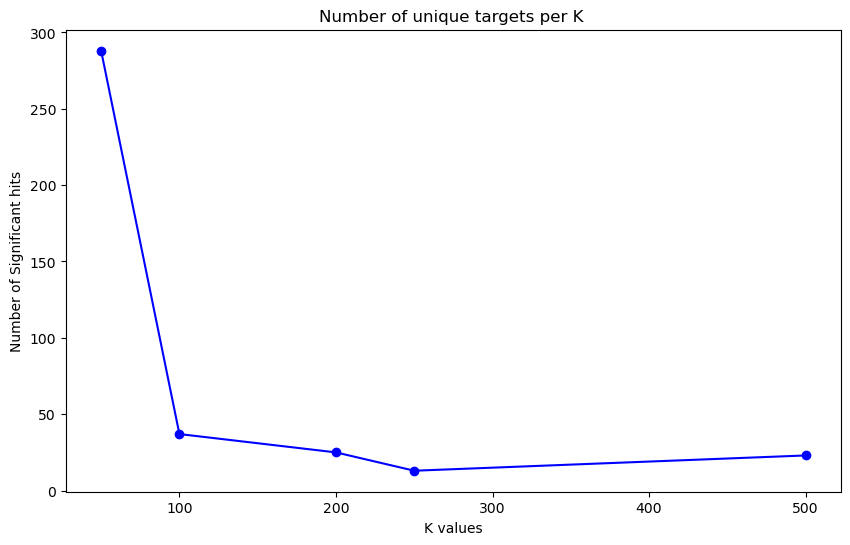

In [ ]:
Ks = list(result_df["Numeric K"])
unique_counts = list(result_df["Unique Gene Count"])
plt.figure(figsize=(10, 6))
plt.plot(Ks, unique_counts, marker='o', linestyle='-', color='b')
plt.title('Number of unique targets per K ')
plt.xlabel('K values')
plt.ylabel('Number of Significant hits')
plt.savefig("unique_Targets_K.pdf")
plt.show()


/tmp/ipykernel_2209101/1515855767.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


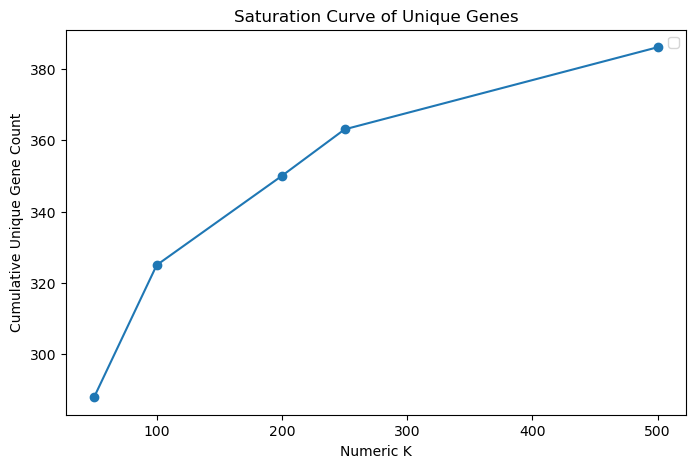

In [ ]:
# Compute the cumulative sum of unique gene counts
result_df['Cumulative Unique Gene Count'] = result_df['Unique Gene Count'].cumsum()

plt.figure(figsize=(8, 5))
plt.plot(result_df['Numeric K'], result_df['Cumulative Unique Gene Count'], marker='o', linestyle='-')
plt.xlabel('Numeric K')
plt.ylabel('Cumulative Unique Gene Count')
plt.title('Saturation Curve of Unique Genes')
plt.legend()
plt.show()

In [ ]:

# Assume cNMF_output_dict_all_Ks is already defined and contains your data
top_genes_dict = {}

# Loop through each K value
for K in K_values:
    gep_zscore = cNMF_output_dict_all_Ks[f"gep_scores_k_{K}"]  # Access the DataFrame directly
    top_genes = []
    ngenes = 300
    
    for gep in gep_zscore.columns:
        # Sort and get the top genes
        top_genes.append(list(gep_zscore.sort_values(by=gep, ascending=False).index[:ngenes]))
    
    # Store the result in a dictionary with K as the key
    top_genes_dict[K] = pd.DataFrame(top_genes, index=gep_zscore.columns).T

# Now top_genes_dict contains top genes for each K



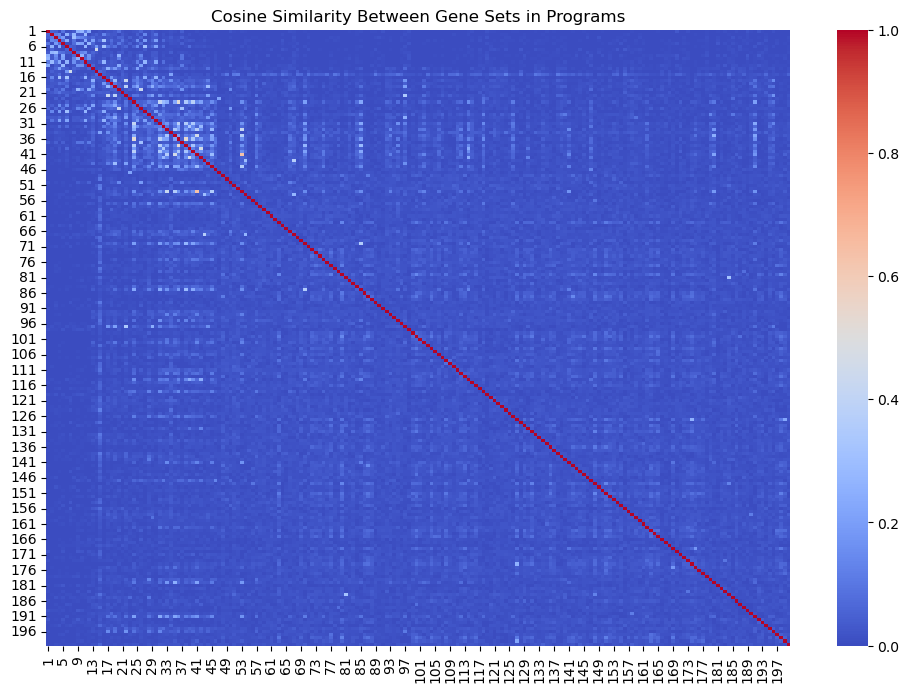

In [ ]:
# Assuming 'Top_genes_300' is a DataFrame (300 rows × 200 columns) with gene names
Top_genes_300=top_genes_dict[200]
# Step 1: Get a list of all unique genes across all columns
all_genes = list(pd.unique(Top_genes_300.values.ravel()))  # Flatten and get unique genes

# Step 2: Create a binary matrix (rows: unique genes, cols: original columns)
binary_matrix = pd.DataFrame(0, index=all_genes, columns=Top_genes_300.columns)

# Step 3: Fill matrix with 1s where a gene is present in a column
for col in Top_genes_300.columns:
    binary_matrix.loc[Top_genes_300[col].dropna(), col] = 1

# Step 4: Compute cosine similarity between columns
cosine_sim = cosine_similarity(binary_matrix.T)  # Transpose to compare columns

# Step 5: Convert to DataFrame for better visualization
cosine_sim_df = pd.DataFrame(cosine_sim, index=Top_genes_300.columns, columns=Top_genes_300.columns)

# Step 6: Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cosine_sim_df, cmap="coolwarm", annot=False)
plt.title("Cosine Similarity Between Gene Sets in Programs")

plt.savefig("K_200_top_300_genes_cosine_similarity_heatmap.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
with open('Prod1_neuron_GO_all_enriched_results.pkl', 'rb') as file:
    enrichment_results = pickle.load(file)

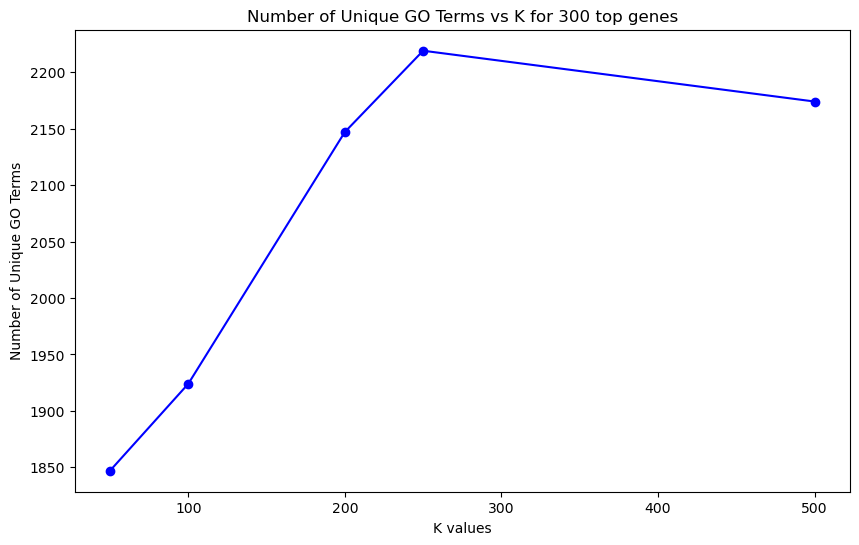

In [ ]:

# Assuming you have a dictionary of DataFrames `dfs_dict`
filtered_dict = {}

# Loop through each key-value pair in the original dictionary
for key, df in enrichment_results.items():
    # Check if the adjusted p-value column exists
    if 'Adjusted P-value' in df.columns:
        # Filter rows where the adjusted p-value is less than 0.05
        filtered_df = df[df['Adjusted P-value'] < 0.05]
        
        # Store the filtered DataFrame in the new dictionary
        filtered_dict[key] = filtered_df

# Now filtered_dict contains the filtered DataFrames where adjusted p-value < 0.05

# Initialize a dictionary to hold counts of unique terms for each K
unique_terms_count = {}

K_values = [k for k in K_values if k in filtered_dict]

# Loop through each K value in filtered_results_dict
for K in K_values:
    terms_set = set()  # Use a set to store unique terms for the current K
    
    # Get the filtered results for current K
    enrich_results = filtered_dict[K]
    
 

    terms_set.update(enrich_results['Term'].unique())
    
    # Store the count of unique terms for this K
    unique_terms_count[K] = len(terms_set)

# Now unique_terms_count contains the number of unique GO terms for each K


import matplotlib.pyplot as plt

# Prepare data for plotting
Ks = list(unique_terms_count.keys())
unique_counts = list(unique_terms_count.values())

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(Ks, unique_counts, marker='o', linestyle='-', color='b')
plt.title('Number of Unique GO Terms vs K for 300 top genes')
plt.xlabel('K values')
plt.ylabel('Number of Unique GO Terms')
plt.savefig("/project/Neuroinformatics_Core/Chahrour_lab/s217793/IGVF/production1/manuscript_analysis/gene_program_analysis/GO_unique_terms.pdf")
plt.show()

